In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 500)

In [3]:
import sys
from pathlib import Path

# Agregar la carpeta raíz al path para poder importar
carpeta_raiz = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(carpeta_raiz))

# Importar las funciones
from funciones_save_load import guardar_parquet, cargar_parquet

# Usar las funciones
icfes = cargar_parquet("icfes_analizado.parquet")
icfes.sample(6)

,tipo_documento,nacionalidad,genero,pertenece_etnia,estrato_casa,num_personas_casa,cuartos_casa,educacion_padre,educacion_madre,actividad_padre,actividad_madre,internet,tv,computador,lavadora,microndas,carro,moto,consola,num_libros_casa,come_derivados_leche,come_carne_pescado_huevo,come_cereal_frutas_legumbres,situacion_economica,cuanto_lee,cuanto_navega_web,horas_trabajo_semanal,tipo_pago_trabajo,colegio_genero,colegio_oficial,colegio_calendario,colegio_bilingue,tipo_colegio,colegio_sede_principal,colegio_urbano_rural,colegio_jornada,mpio_colegio,dpto_colegio,puntaje_lectura,puntaje_matematicas,puntaje_naturales,puntaje_sociales,puntaje_ingles,puntaje_global,inse_estudiante,nse_estudiantes,nse_colegio,edad,outlier_if,es_outlier,rango_puntaje,educacion_padres,nivel_libros,nivel_lectura,perfil_lector
420409,TI,Colombia,Masculino,No,Estrato 1,5 a 6,Tres,Ninguna,Bachiller incompleta,Microempresario,Sin actividad remunerada,Si,Si,No,No,Si,No,No,No,11 a 25 libros,3 a 5 veces por semana,1 o 2 veces por semana,1 o 2 veces por semana,Igual,30 minutos o menos,Entre 1 y 3 horas,No trabaja,No aplica,Mixto,Oficial,A,No,Técnico/académico,Si,Urbano,Unica,Málaga,Santander,54,44,46,50,41.0,240,46.074855,2.0,2.0,17.0,False,False,201-300,Educación Secundaria Incompleta,Bajo,Bajo,"Poco Apoyo, Poco Habito"
62058,TI,Colombia,Masculino,Si,Estrato 1,1 a 2,Dos,Bachiller incompleta,Bachiller,Trabajadores operativos,Sin actividad remunerada,Si,Si,Si,No,No,No,No,No,0 a 10 libros,1 o 2 veces por semana,1 o 2 veces por semana,1 o 2 veces por semana,Peor,30 minutos o menos,Entre 1 y 3 horas,No trabaja,No aplica,Mixto,Oficial,A,No,Académico,Si,Urbano,Tarde,Ipiales,Nariño,61,56,46,51,51.0,267,48.032527,2.0,3.0,17.0,False,False,201-300,Al Menos Un Bachiller,Bajo,Bajo,"Poco Apoyo, Poco Habito"
488888,TI,Colombia,Masculino,No,Estrato 5,3 a 4,Cuatro,Bachiller,Profesional,Directivos,Trabajadores operativos,Si,Si,Si,Si,Si,Si,Si,Si,11 a 25 libros,Todos o casi todos los días,Todos o casi todos los días,1 o 2 veces por semana,Igual,No leo por entretenimiento,Entre 30 y 60 minutos,No trabaja,No aplica,Mixto,No oficial,A,No,Académico,Si,Urbano,Completa,Medellín,Antioquia,56,59,39,45,40.0,245,66.077046,4.0,3.0,16.0,False,False,201-300,Educación Superior,Bajo,Bajo,"Poco Apoyo, Poco Habito"
393545,CR,Colombia,Masculino,Si,Estrato 1,5 a 6,Dos,Primaria incompleta,Bachiller,Sector primario,Sin actividad remunerada,No,Si,No,Si,Si,No,Si,No,Más de 100 libros,Nunca o rara vez comemos eso,3 a 5 veces por semana,Nunca o rara vez comemos eso,Igual,Entre 30 y 60 minutos,Entre 30 y 60 minutos,Tiempo parcial reducido,Sin pago,Mixto,Oficial,A,No,Académico,Si,Rural,Mañana,Lorica,Cordoba,44,36,42,34,41.0,196,40.894333,1.0,1.0,18.0,False,False,101-200,Al Menos Un Bachiller,Alto,Alto,"Buen Apoyo, Buen Habito"
327503,TI,Colombia,Masculino,No,Estrato 2,3 a 4,Dos,Postgrado,Profesional,Profesionales,Profesionales,Si,No,Si,Si,Si,Si,No,No,26 a 100 libros,3 a 5 veces por semana,3 a 5 veces por semana,1 o 2 veces por semana,Igual,Entre 30 y 60 minutos,Entre 1 y 3 horas,No trabaja,No aplica,Mixto,No oficial,A,No,Académico,Si,Urbano,Sabatina,Tunja,Boyaca,54,63,53,63,58.0,291,65.960057,4.0,3.0,17.0,False,False,201-300,Educación Superior,Alto,Alto,"Buen Apoyo, Buen Habito"
238203,CC,Colombia,Femenino,No,Estrato 1,7 a 8,Dos,Bachiller incompleta,Primaria,Sector primario,Sin actividad remunerada,No,No,No,Si,Si,No,Si,No,0 a 10 libros,Nunca o rara vez comemos eso,1 o 2 veces por semana,3 a 5 veces por semana,Igual,Entre 30 y 60 minutos,Entre 1 y 3 horas,No trabaja,No aplica,Mixto,Oficial,A,No,Académico,Si,Rural,Unica,Cereté,Cordoba,43,40,45,38,41.0,207,38.845269,1.0,1.0,19.0,False,False,201-300,Educación Primaria,Bajo,Alto,"Poco Apoyo, Buen Habito"


In [4]:
icfes['presento_fuera_edad'] = (icfes['edad'] > 19).astype(int)

In [5]:
departamento_a_region = {
    # Región Andina
    'Antioquia': 'Andina', 'Boyaca': 'Andina', 'Caldas': 'Andina', 'Cundinamarca': 'Andina',
    'Huila': 'Andina', 'Norte santander': 'Andina', 'Quindio': 'Andina',
    'Risaralda': 'Andina', 'Santander': 'Andina', 'Tolima': 'Andina', 'Bogotá': 'Andina',

    # Región Caribe
    'Atlantico': 'Caribe', 'Bolivar': 'Caribe', 'Cesar': 'Caribe', 'Cordoba': 'Caribe',
    'La guajira': 'Caribe', 'Magdalena': 'Caribe', 'Sucre': 'Caribe','San andres': 'Caribe',

    # Región Pacífica
    'Cauca': 'Pacífica', 'Choco': 'Pacífica', 'Nariño': 'Pacífica', 'Valle': 'Pacífica',

    # Región Orinoquía
    'Meta': 'Orinoquía', 'Arauca': 'Orinoquía', 'Casanare': 'Orinoquía', 'Vichada': 'Orinoquía',

    # Región Amazónica
    'Caqueta': 'Amazónica', 'Putumayo': 'Amazónica', 'Amazonas': 'Amazónica',
    'Guainia': 'Amazónica', 'Guaviare': 'Amazónica', 'Vaupes': 'Amazónica'
}

# Crear la nueva variable 'region' en el dataframe ICFES
icfes['region'] = icfes['dpto_colegio'].map(departamento_a_region)

# Verificar si hay departamentos sin asignación
print(icfes[icfes['region'].isna()]['dpto_colegio'].unique())

[NaN]
Categories (33, object): ['Amazonas', 'Antioquia', 'Arauca', 'Atlantico', ..., 'Tolima', 'Valle', 'Vaupes', 'Vichada']


In [6]:
icfes = icfes.drop(columns=['situacion_economica', 'tipo_pago_trabajo', 'colegio_calendario', 'colegio_sede_principal', 'mpio_colegio', 'genero', 
                            'puntaje_lectura', 'puntaje_matematicas', 'puntaje_naturales', 'puntaje_sociales', 'puntaje_ingles', 'inse_estudiante','dpto_colegio',
                            'nse_estudiantes', 'nse_colegio', 'outlier_if', 'es_outlier', 'rango_puntaje', 'tipo_documento', 'nivel_libros', 'nivel_lectura'])

icfes.shape

(504790, 36)

## 1. División de Datos

In [7]:
from sklearn.model_selection import train_test_split

# Suponiendo que 'puntaje_global' es la variable objetivo (Y)
X = icfes.drop(columns=['puntaje_global'])  # Características
y = icfes['puntaje_global']  # Variable objetivo

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Train
count    403832.000000
mean        248.354123
std          48.617790
min          11.000000
25%         211.000000
50%         245.000000
75%         282.000000
max         500.000000
Name: puntaje_global, dtype: float64

Test
count    100958.000000
mean        248.517780
std          48.503834
min          12.000000
25%         212.000000
50%         245.000000
75%         282.000000
max         492.000000
Name: puntaje_global, dtype: float64


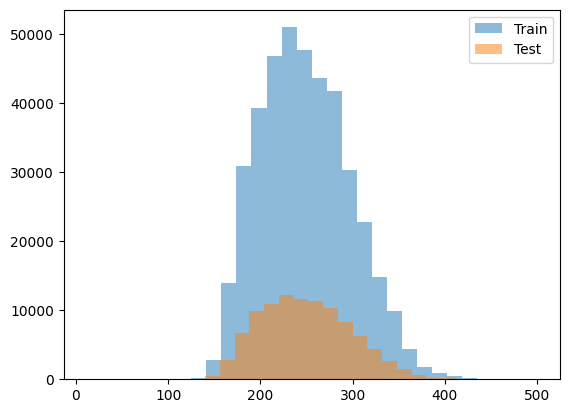

In [8]:
for split, data in zip(
    ["Train", "Test"],
    [y_train, y_test]
):
    print(f"\n{split}")
    print(data.describe())
    
plt.hist(y_train, bins=30, alpha=0.5, label="Train")
plt.hist(y_test, bins=30, alpha=0.5, label="Test")
plt.legend()
plt.show()

In [9]:
q_low, q_high = y.quantile([0.01, 0.99])  # percentiles extremos
extremos = icfes[(y <= q_low) | (y >= q_high)]

print("Valores extremos totales:", len(extremos))
print("Distribución en train/test:")
print((y_train <= q_low).sum(), (y_test <= q_low).sum())

Valores extremos totales: 10461
Distribución en train/test:
4092 1021


## 2. Exportar Archivos

In [10]:
from funciones_save_load import guardar_parquet

guardar_parquet(X_train, "x_train.parquet")
guardar_parquet(X_test, "x_test.parquet")
guardar_parquet(y_train, "y_train.parquet")
guardar_parquet(y_test, "y_test.parquet")

Archivo guardado en la carpeta data con el nombre de x_train.parquet
Archivo guardado en la carpeta data con el nombre de x_test.parquet
Archivo guardado en la carpeta data con el nombre de y_train.parquet
Archivo guardado en la carpeta data con el nombre de y_test.parquet
